# 데이터 불러오기

In [6]:
# 필수 통계 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats

In [7]:
# 한국어 폰트 설정
import platform, matplotlib
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
else:
    # Linux / Colab
    matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# 경고 억제 및 출력 설정
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [20]:
# 1. 파일 불러오기 (기본)
# portfolio.csv
df_portfolio = pd.read_csv('portfolio.csv', index_col=0)

# profile.csv
df_profile = pd.read_csv('profile.csv', index_col=0)

# starbucks_menu_260112.csv
df_menus = pd.read_csv('starbucks_menu_260112.csv', index_col=0)

# transcript.csv (용량이 클 경우 대비)
df_transcript = pd.read_csv('transcript.csv', index_col=0)

# 데이터 구조 확인

In [ ]:
# 2. 데이터 확인 (첫 5행)
print(f"="*30, 'portfolio')
display(df_portfolio.head())
print("reward:      프로모션 결과로 제공되는 리워드 금액")
print("channels:    고객에게 프로모션이 전달되는 마케팅 채널, 여러 채널이 동시에 주어질 수 있음")
print("difficulty:  프로모션을 완료하기 위해 필요한 최소 지출 금액, ex) difficulty=10 -> 최소 10달러 지출 필요")
print("duration:    프로모션 유효 기간(일 단위)")
print("offer_type:  프로모션 유형")
print("id:          프로모션 고유 ID")


============================== portfolio


,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


reward:      프로모션 결과로 제공되는 리워드 금액
channels:    고객에게 프로모션이 전달되는 마케팅 채널, 여러 채널이 동시에 주어질 수 있음
difficulty:  프로모션을 완료하기 위해 필요한 최소 지출 금액, ex) difficulty=10 -> 최소 10달러 지출 필요
duration:    프로모션 유효 기간(일 단위)
offer_type:  프로모션 유형
id:          프로모션 고유 ID


In [23]:
print(f"="*30, 'profile')
display(df_profile.head())
print("gender:           고객 성별")
print("age:              고객 나이")
print("id:               고객 고유 ID")
print("became_member_on: 멤버십 가입일, YYYYMMDD형식")
print("income:           연간 소득(달러 단위)")

============================== profile


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0000
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0000
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


gender:           고객 성별
age:              고객 나이
id:               고객 고유 ID
became_member_on: 멤버십 가입일, YYYYMMDD형식
income:           연간 소득(달러 단위)


In [27]:
print(f"="*30, 'transcript')
display(df_transcript.head())
print("person:      고객 고유 ID")
print("event:       record에 대한 정보(이벤트 유형)")
print("     - transaction:      거래")
print("     - offer received:   프로모션 받음")
print("     - offer viewed:     프로모션 확인")
print("     - offer completed:  프로모션 완료")
print("value:       이벤트 별 상세 정보")
print("     - (event=transaction): amount: 거래 금액")
print("     - offer id: 프로모션 ID, 일부 거래 이벤트에는 거래 id나 보너스 여부 같은 추가 key가 포함될 수 있음")
print("     - 이벤트 유형에 따라 포함되는 key가 달라진다 -> event를 기준으로 분기 처리")
print("time:        시간 정보(데이터 내 상대적 시간, t=0부터 시작)")

============================== transcript


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


person:      고객 고유 ID
event:       record에 대한 정보(이벤트 유형)
     - transaction:      거래
     - offer received:   프로모션 받음
     - offer viewed:     프로모션 확인
     - offer completed:  프로모션 완료
value:       이벤트 별 상세 정보
     - (event=transaction): amount: 거래 금액
     - offer id: 프로모션 ID, 일부 거래 이벤트에는 거래 id나 보너스 여부 같은 추가 key가 포함될 수 있음
     - 이벤트 유형에 따라 포함되는 key가 달라진다 -> event를 기준으로 분기 처리
time:        시간 정보(데이터 내 상대적 시간, t=0부터 시작)


In [28]:
df_transcript['value'].value_counts()

value
{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'}    14983
{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}    14924
{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}    14891
{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}    14835
{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}    14374
                                                    ...  
{'amount': 39.54}                                       1
{'amount': 306.99}                                      1
{'amount': 49.73}                                       1
{'amount': 749.29}                                      1
{'amount': 286.81}                                      1
Name: count, Length: 5121, dtype: int64

In [26]:
print(f"="*30, 'menus')
display(df_menus)

============================== menus


,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
0,9200000002487,나이트로 바닐라 크림,80,2,1,2.7,0,40,10,232,5,10
1,9200000000479,나이트로 콜드 브루,5,0,0,0,0,5,0,245,0,0
2,9200000002081,돌체 콜드 브루,220,6,6,10,0,80,22,155,20,24
3,9200000002407,리저브 나이트로,5,0,0,0,0,0,0,190,0,0
4,9200000002093,리저브 콜드 브루,5,0,0,0,0,0,0,190,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
190,9200000003255,아이스 더블 에스프레소 크림 라떼,190,7,5,9,0,85,20,90,15,21
191,9200000006643,아이스 프렌즈 얼 그레이 베리 티 라떼,280,12,4,15,0,60,26,30,15,33
192,9200000006640,프렌즈 얼 그레이 베리 티 라떼,280,12,4,15,0,60,26,30,15,33
193,9200000006646,유자 배 캐모마일 티,190,0,0,0.2,0,0,33,0,0,52


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 데이터 불러오기
portfolio = pd.read_csv('portfolio.csv', index_col=0)
profile = pd.read_csv('profile.csv', index_col=0)
transcript = pd.read_csv('transcript.csv', index_col=0)
menu = pd.read_csv('starbucks_menu_260112.csv', index_col=0)

# profile 전처리: 날짜 변환 및 118세(결측치) 처리
profile['became_member_on'] = pd.to_datetime(profile['became_member_on'], format='%Y%m%d')
profile.loc[profile['age'] == 118, ['gender', 'age', 'income']] = np.nan

# transcript 전처리: 'value' 컬럼 파싱 (offer_id / amount 추출)
def extract_value(val):
    val_dict = json.loads(val.replace("'", "\""))
    if 'offer id' in val_dict:
        return val_dict['offer id'], np.nan
    elif 'offer_id' in val_dict:
        return val_dict['offer_id'], np.nan
    elif 'amount' in val_dict:
        return np.nan, val_dict['amount']
    return np.nan, np.nan

transcript[['offer_id', 'amount']] = transcript['value'].apply(lambda x: pd.Series(extract_value(x)))

print("Data Loaded Successfully!")


Data Loaded Successfully!


In [30]:
transcript

,person,event,value,time,offer_id,amount
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN
...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714,NaN,1.5900
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714,NaN,9.5300
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714,NaN,3.6100
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714,NaN,3.5300


In [31]:
profile

,gender,age,id,became_member_on,income
0,NaN,NaN,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN
1,F,55.0000,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0000
2,NaN,NaN,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN
3,F,75.0000,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0000
4,NaN,NaN,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN
...,...,...,...,...,...
16995,F,45.0000,6d5f3a774f3d4714ab0c092238f3a1d7,2018-06-04,54000.0000
16996,M,61.0000,2cb4f97358b841b9a9773a7aa05a9d77,2018-07-13,72000.0000
16997,M,49.0000,01d26f638c274aa0b965d24cefe3183f,2017-01-26,73000.0000
16998,F,83.0000,9dc1421481194dcd9400aec7c9ae6366,2016-03-07,50000.0000


In [32]:
portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


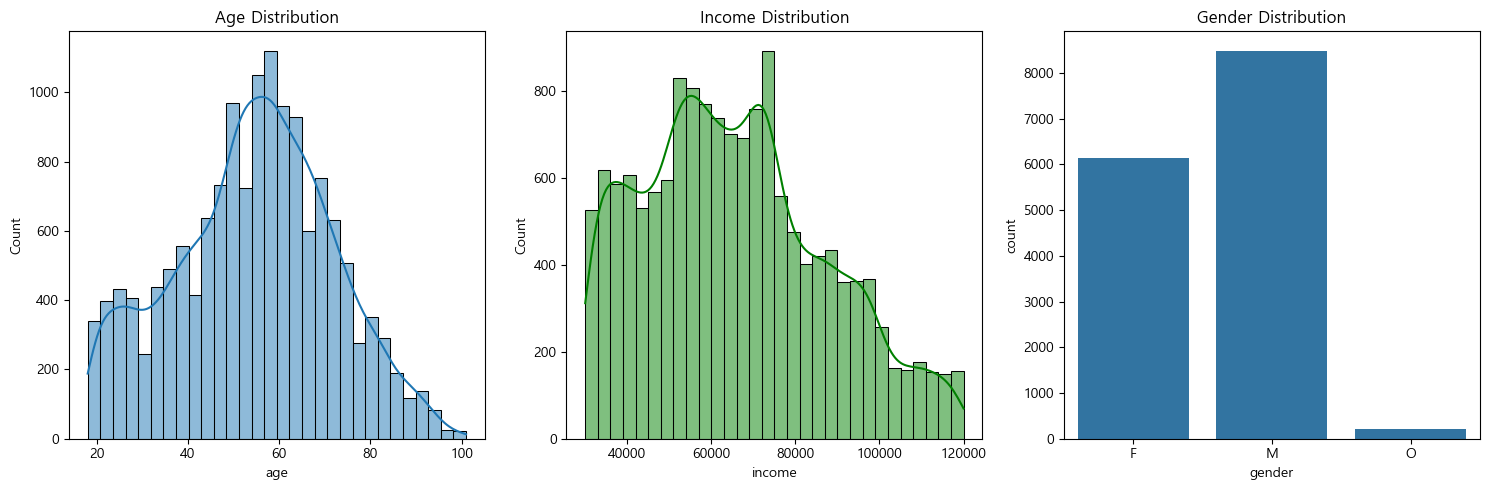

In [33]:
plt.figure(figsize=(15, 5))

# 나이 분포
plt.subplot(1, 3, 1)
sns.histplot(profile['age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')

# 수입 분포
plt.subplot(1, 3, 2)
sns.histplot(profile['income'].dropna(), bins=30, kde=True, color='green')
plt.title('Income Distribution')

# 성별 분포
plt.subplot(1, 3, 3)
sns.countplot(data=profile, x='gender')
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()


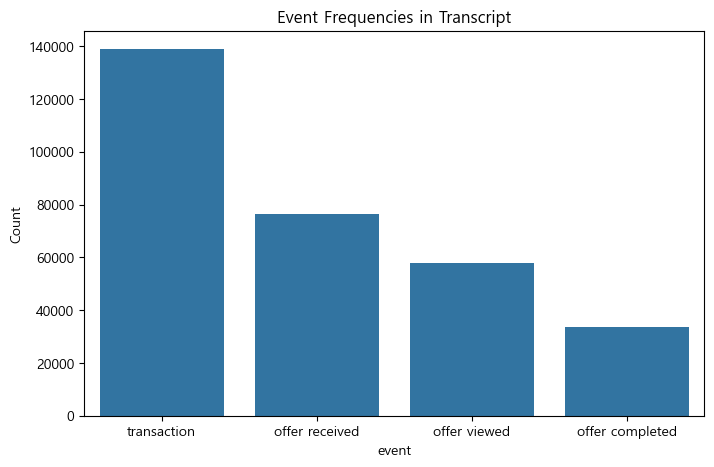

In [34]:
event_counts = transcript['event'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=event_counts.index, y=event_counts.values)
plt.title('Event Frequencies in Transcript')
plt.ylabel('Count')
plt.show()


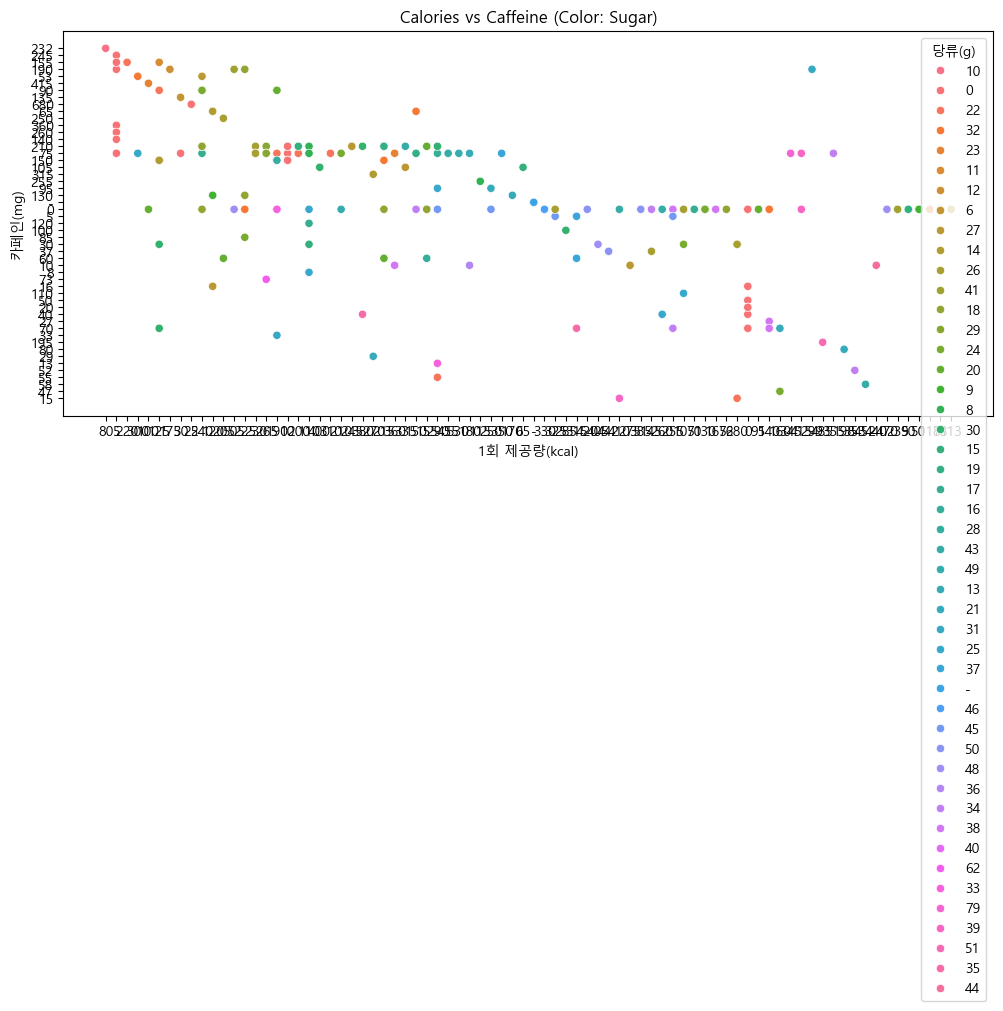

In [35]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=menu, x='1회 제공량(kcal)', y='카페인(mg)', hue='당류(g)')
plt.title('Calories vs Caffeine (Color: Sugar)')
plt.show()
